In [20]:
import sys
import os

path_to_scripts = os.path.join('..', '..', 'python_scripts')
sys.path.append(path_to_scripts)

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_error, max_error

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit

from data_to_bigquery import load_from_bigquery
from feature_engineering import drop_lag_nulls, validate_features, engineer_features
from baseline_model import baseline_model_xgb, xgb_train_preproc, evaluate_trained_model, pred_preproc_xgb, xgb_prediction


%matplotlib inline

# Code to do split based on input date 

In [ ]:
# test train split for more years
# df = df.sort_values('datetime').copy()

# split_date = '2025-10-01'

# train_df = df[df['datetime'] < split_date]
# test_df = df[df['datetime'] >= split_date]

# X_train = train_df.drop(columns=['carbon_intensity', 'datetime'])
# y_train = train_df['carbon_intensity']

# X_test = test_df.drop(columns=['carbon_intensity', 'datetime'])
# y_test = test_df['carbon_intensity']

# Function checking 

In [22]:
# raw table
df_raw = load_from_bigquery('gridzero-489711', 'merged_set', 'test_merge_2017_onward_raw')
# display(df_raw.head())
# df_raw.columns

/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 148,991 rows and 26 columns from gridzero-489711.merged_set.test_merge_2017_onward_raw


In [23]:
# train preproc function
df_pre = xgb_train_preproc(df_raw, add_year_lag=True)
df_pre
# success working!

,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,snowfall_cm,...,TotalOutput-MW,carbon_intensity_gCO2_kWh,status,lag_48,lag_336,lag_17520,hour,day_of_week,month,is_weekend
17520,2018-09-12 00:00:00,16.5,17.1,21.2,100,0.0,0.0,0.0,1019.2,0.0,...,20739.832,150.0,okay,122.0,244.0,142.0,0,2,9,0
17521,2018-09-12 00:30:00,16.5,17.1,21.2,100,0.0,0.0,0.0,1019.2,0.0,...,20600.825,147.0,okay,124.0,252.0,140.0,0,2,9,0
17522,2018-09-12 01:00:00,16.1,15.7,15.1,100,0.0,0.0,0.0,1018.8,0.0,...,20498.196,152.0,okay,128.0,248.0,139.0,1,2,9,0
17523,2018-09-12 01:30:00,16.1,15.7,15.1,100,0.0,0.0,0.0,1018.8,0.0,...,20427.333,150.0,okay,127.0,247.0,137.0,1,2,9,0
17524,2018-09-12 02:00:00,15.9,16.1,13.3,100,0.0,0.0,0.0,1019.4,0.0,...,20070.633,146.0,okay,123.0,252.0,132.0,2,2,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148939,2026-03-11 21:30:00,7.6,26.0,29.9,50,0.0,0.0,0.0,1018.0,0.0,...,31433.495,87.0,okay,73.0,119.0,181.0,21,2,3,0
148940,2026-03-11 22:00:00,7.3,26.4,30.2,86,0.0,0.0,0.0,1018.3,0.0,...,31148.429,77.0,okay,65.0,100.0,168.0,22,2,3,0
148941,2026-03-11 22:30:00,7.3,26.4,30.2,86,0.0,0.0,0.0,1018.3,0.0,...,30511.622,78.0,okay,64.0,83.0,149.0,22,2,3,0
148942,2026-03-11 23:00:00,7.0,24.8,29.9,70,0.0,0.0,0.0,1018.3,0.0,...,30607.883,78.0,okay,55.0,76.0,136.0,23,2,3,0


In [24]:
# checking train_preproc
print(df_raw.shape)
print(df_pre.shape)
print(df_pre.columns.tolist())
print(df_pre.isna().sum().sum())
# success working!

(148991, 26)
(126157, 33)
['datetime', 'temperature_2m_c', 'wind_speed_100m_ms', 'wind_gusts_10m_ms', 'cloud_cover_pct', 'shortwave_radiation_wm2', 'direct_radiation_wm2', 'diffuse_radiation_wm2', 'pressure_msl_hpa', 'snowfall_cm', 'rain_mm', 'precipitation_mm', 'Biomass', 'Fossil Gas', 'Fossil Hard coal', 'Fossil Oil', 'Hydro Pumped Storage', 'Hydro Run-of-river and poundage', 'Nuclear', 'Other', 'Solar', 'Wind Offshore', 'Wind Onshore', 'TotalOutput-MW', 'carbon_intensity_gCO2_kWh', 'status', 'lag_48', 'lag_336', 'lag_17520', 'hour', 'day_of_week', 'month', 'is_weekend']
0


In [25]:
# checking model function
model, X_train, X_test, y_train, y_test = baseline_model_xgb()
# success working!

/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 148,991 rows and 26 columns from gridzero-489711.merged_set.test_merge_2017_onward_raw


In [113]:
# evaluate trained model
metrics = evaluate_trained_model(model, X_test, y_test)
print(metrics)

{'MAE': 6.918479433492205, 'RMSE': 9.132103535598977, 'R2': 0.9757832656293409, 'MaxError': 59.277130126953125}


In [27]:
# pred_preproc using X_test as df_new to check fucntion is working
#takes model ouput X_train
feature_cols = X_train.columns.tolist()

X_new = pred_preproc_xgb(df_new=X_test.copy(),
                     feature_cols=feature_cols
                     )

print(X_new.shape)
print(X_new.columns.tolist() == feature_cols)
print(X_new.isna().sum().sum())

(43035, 29)
True
0


In [28]:
# checking prediction fucntion
prediction = xgb_prediction(
            model=model,
            df_new=X_test.copy(),
            feature_cols=feature_cols
            )

print(type(prediction))
print(len(prediction))
print(prediction[:5])

<class 'numpy.ndarray'>
43035
[229.6808  146.74657 212.47081 159.01811 309.9817 ]


## CVGridsearch for params

# Splitting

In [29]:
# loading data
df = load_from_bigquery('gridzero-489711', 'merged_set', 'test_merge_2017_onward_raw')
# df = xgb_train_preproc(df)

/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded 148,991 rows and 26 columns from gridzero-489711.merged_set.test_merge_2017_onward_raw


In [ ]:
# preproc
# defining X and target
# keeping dattime to help plotting
# splitting temporally bc multiple years

df = xgb_train_preproc(df)
target_col = 'carbon_intensity_gCO2_kWh'

# sort by datetime and reset index ooooo
df = df.sort_values('datetime').reset_index(drop=True)

target_col = 'carbon_intensity_gCO2_kWh'

# split option 1: by granular date
# split_date = '2024-01-01'
# train_df = df[df['datetime'] < split_date]
# test_df = df[df['datetime'] >= split_date]

# split option 2: by year
split_year = 2024
train_df = df[df['datetime'].dt.year < split_year]
test_df  = df[df['datetime'].dt.year >= split_year]

X_train = train_df.drop(columns=[target_col, 'datetime'])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col, 'datetime'])
y_test = test_df[target_col]

# keep only num cola to make xgboost happy
feature_cols = X_train.select_dtypes(include='number').columns.tolist()

X_train = X_train[feature_cols]
X_test = X_test[feature_cols]


In [ ]:
# model split function

# def temporal_split(df, split_date, target):
#     df = df.sort_values('datetime')

#     train_df = df[df['datetime'] < split_date]
#     test_df  = df[df['datetime'] >= split_date]

#     X_train = train_df.drop(columns=[target, 'datetime'])
#     y_train = train_df[target]

#     X_test = test_df.drop(columns=[target, 'datetime'])
#     y_test = test_df[target]

#     return X_train, X_test, y_train, y_test

# Model tuning 

In [ ]:
# Baseline model from 2025 dataset

# Best params: {'learning_rate': np.float64(0.05), 'max_depth': np.int64(6), 'n_estimators': np.int64(1750)}
# MAE: 4.271311283111572
# RMSE: 5.715928011996834
# R2: 0.990020215511322
# Max Error: 35.22937774658203

# baseline_model = XGBRegressor(
#     learning_rate=0.05,
#     n_estimators=1750,
#     max_depth=6
#     )


In [ ]:
# Example XGBoost pipeline
#
# pipeline = pipeline = make_pipeline(
#         StandardScaler(),
#         XGBRegressor(
#             n_estimators=2000,
#             learning_rate=0.03,
#             max_depth=5,
#             subsample=0.8,
#             colsample_bytree=0.8,
#             reg_alpha=0.1,
#             reg_lambda=1.0,
#             #histo
#             tree_method='hist',
#             random_state=42
#             )
#         )


In [ ]:
# base model
xgb_stage1 = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# scoring metrics
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2',
    'max_err':'neg_max_error'
}

# timeseries CV split
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# question ask Arthur about using tscv instead of cv
# from sklearn.model_selection import TimeSeriesSplit
# tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
#Hyperparams search

# stage 1 grid
param_grid_stage1 = {
    'n_estimators': [1250, 1500, 1750, 2000, 2250],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.03, 0.05, 0.07]
}

# grid search
grid_stage1 = GridSearchCV(
    estimator=xgb_stage1,
    param_grid=param_grid_stage1,
    scoring=scoring,
    refit='mae',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)


In [36]:
# stage 1 fit
grid_stage1.fit(X_train, y_train)


Fitting 5 folds for each of 60 candidates, totalling 300 fits


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:32] WARNING: /Users/runner

[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1250; total time=   1.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1500; total time=   2.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1250; total time=   2.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1500; total time=   3.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1250; total time=   3.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1500; total time=   4.1s
[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1250; total time=   4.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1750; total time=   2.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1500; total time=   5.0s
[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1250; total time=   5.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1750; total time=   3.7s
[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1500; total time=   6.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=2000; total time=   2.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1750; total time=   4.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=2000; total time=   4.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1750; total time=   5.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=2250; total time=   3.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=2000; total time=   5.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=1750; total time=   7.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=2250; total time=   4.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1250; total time=   2.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=2000; total time=   6.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1250; total time=   3.7s
[CV] END .learning_rate=0.03, max_depth=4, n_estimators=2250; total time=   6.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=2000; total time=   8.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1250; total time=   4.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1500; total time=   3.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=2250; total time=   7.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1500; total time=   4.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1250; total time=   5.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=4, n_estimators=2250; total time=   9.4s
[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1250; total time=   6.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1750; total time=   3.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1500; total time=   5.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1500; total time=   6.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1750; total time=   5.3s
[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1500; total time=   8.2s
[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1750; total time=   6.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=2000; total time=   4.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=2000; total time=   6.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1750; total time=   8.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=2250; total time=   4.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=2000; total time=   7.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=1750; total time=   9.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:52:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=2000; total time=   9.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=2250; total time=   7.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1250; total time=   4.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=2250; total time=   9.1s
[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1250; total time=   6.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=2000; total time=  11.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=2250; total time=  10.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1250; total time=   7.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1500; total time=   5.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1250; total time=   8.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1500; total time=   6.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=5, n_estimators=2250; total time=  12.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1250; total time=   9.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1750; total time=   6.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1500; total time=   8.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1750; total time=   7.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1500; total time=  10.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1500; total time=  11.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1750; total time=   9.5s
[CV] END .learning_rate=0.03, max_depth=6, n_estimators=2000; total time=   6.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1750; total time=  11.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=2000; total time=   8.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=2250; total time=   7.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=1750; total time=  13.4s
[CV] END .learning_rate=0.03, max_depth=6, n_estimators=2000; total time=  10.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=2000; total time=  12.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=2250; total time=   9.4s
[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1250; total time=   6.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=2000; total time=  14.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=2250; total time=  11.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1250; total time=   8.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=2250; total time=  13.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1250; total time=   9.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1500; total time=   7.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1250; total time=  11.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=6, n_estimators=2250; total time=  16.7s
[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1500; total time=  10.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1250; total time=  13.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1750; total time=   9.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1500; total time=  12.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1500; total time=  13.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1750; total time=  11.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1500; total time=  15.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=2000; total time=   9.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1750; total time=  13.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1750; total time=  15.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=2000; total time=  12.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1250; total time=   2.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=1750; total time=  17.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:52] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=2250; total time=  10.8s
[CV] END .learning_rate=0.03, max_depth=7, n_estimators=2000; total time=  15.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1250; total time=   2.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1250; total time=   3.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=2000; total time=  17.2s
[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1500; total time=   2.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1250; total time=   4.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=2250; total time=  13.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1500; total time=   3.3s
[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1250; total time=   5.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:53:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.03, max_depth=7, n_estimators=2000; total time=  19.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1500; total time=   4.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1750; total time=   2.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1500; total time=   5.3s
[CV] END .learning_rate=0.03, max_depth=7, n_estimators=2250; total time=  16.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1750; total time=   3.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=2000; total time=   2.9s
[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1750; total time=   5.2s
[CV] END .learning_rate=0.03, max_depth=7, n_estimators=2250; total time=  19.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1500; total time=   6.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=2000; total time=   4.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1750; total time=   6.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=2000; total time=   5.8s
[CV] END .learning_rate=0.05, max_depth=4, n_estimators=2250; total time=   3.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=1750; total time=   7.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=2250; total time=   5.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=2000; total time=   7.3s
[CV] END .learning_rate=0.03, max_depth=7, n_estimators=2250; total time=  21.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1250; total time=   3.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=2250; total time=   6.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1250; total time=   4.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1250; total time=   4.9s
[CV] END .learning_rate=0.05, max_depth=4, n_estimators=2000; total time=   8.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1500; total time=   3.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=2250; total time=   8.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1500; total time=   4.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1250; total time=   6.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=4, n_estimators=2250; total time=   9.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1500; total time=   5.6s
[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1750; total time=   3.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1250; total time=   6.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1500; total time=   6.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1750; total time=   5.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=2000; total time=   4.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1750; total time=   6.5s
[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1500; total time=   7.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=2000; total time=   5.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1750; total time=   8.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=2250; total time=   4.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=2000; total time=   7.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=1750; total time=   9.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=2000; total time=   9.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=2250; total time=   6.9s
[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1250; total time=   4.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=2000; total time=  10.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1250; total time=   5.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=2250; total time=   8.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=2250; total time=  10.4s
[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1250; total time=   7.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1500; total time=   5.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1250; total time=   8.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1500; total time=   6.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=5, n_estimators=2250; total time=  12.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1250; total time=   9.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1500; total time=   7.8s
[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1750; total time=   5.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1500; total time=   9.6s
[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1750; total time=   7.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1500; total time=  10.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=2000; total time=   6.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1750; total time=   9.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1750; total time=  10.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=2000; total time=   8.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=2250; total time=   7.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=1750; total time=  13.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=2000; total time=  10.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=2000; total time=  12.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=2250; total time=  10.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1250; total time=   6.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=2000; total time=  14.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=2250; total time=  12.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1250; total time=   8.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=2250; total time=  14.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:57] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1250; total time=  10.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1500; total time=   7.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1250; total time=  11.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:54:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=6, n_estimators=2250; total time=  16.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1500; total time=   9.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1250; total time=  12.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:03] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1750; total time=   8.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1500; total time=  11.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1500; total time=  13.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1750; total time=  10.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1500; total time=  15.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=2000; total time=   9.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:10] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1750; total time=  13.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1750; total time=  15.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=2000; total time=  12.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1250; total time=   1.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=1750; total time=  17.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=2250; total time=  10.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1250; total time=   3.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=2000; total time=  15.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1250; total time=   4.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1500; total time=   2.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=2000; total time=  17.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1250; total time=   4.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=2250; total time=  14.1s
[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1500; total time=   3.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1250; total time=   5.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1750; total time=   2.7s
[CV] END .learning_rate=0.05, max_depth=7, n_estimators=2000; total time=  19.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1500; total time=   4.6s
[CV] END .learning_rate=0.05, max_depth=7, n_estimators=2250; total time=  17.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1500; total time=   5.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1750; total time=   4.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=2000; total time=   3.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1500; total time=   6.9s
[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1750; total time=   5.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=2250; total time=  19.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=2000; total time=   4.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1750; total time=   6.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=2250; total time=   3.3s
[CV] END .learning_rate=0.07, max_depth=4, n_estimators=2000; total time=   5.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=1750; total time=   7.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=2250; total time=   4.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.05, max_depth=7, n_estimators=2250; total time=  22.2s
[CV] END .learning_rate=0.07, max_depth=4, n_estimators=2000; total time=   7.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1250; total time=   2.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=2250; total time=   6.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1250; total time=   3.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=2000; total time=   8.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1250; total time=   4.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1500; total time=   3.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=2250; total time=   8.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1500; total time=   4.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1250; total time=   5.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=4, n_estimators=2250; total time=   9.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1500; total time=   5.8s
[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1250; total time=   6.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1750; total time=   4.0s
[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1500; total time=   7.3s
[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1750; total time=   5.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1750; total time=   7.1s
[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1500; total time=   8.6s
[CV] END .learning_rate=0.07, max_depth=5, n_estimators=2000; total time=   4.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=2000; total time=   6.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1750; total time=   8.2s
[CV] END .learning_rate=0.07, max_depth=5, n_estimators=2250; total time=   4.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:50] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=2000; total time=   7.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=1750; total time=   9.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=2000; total time=   9.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1250; total time=   3.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=2250; total time=   6.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:54] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1250; total time=   5.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=2000; total time=  10.7s
[CV] END .learning_rate=0.07, max_depth=5, n_estimators=2250; total time=   8.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1250; total time=   6.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=2250; total time=  10.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1500; total time=   5.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1250; total time=   8.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:55:59] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1500; total time=   6.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:01] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=5, n_estimators=2250; total time=  12.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1250; total time=   9.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1750; total time=   5.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1500; total time=   8.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1500; total time=   9.9s
[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1750; total time=   7.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1500; total time=  11.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:07] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1750; total time=   9.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=2000; total time=   6.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1750; total time=  11.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=2000; total time=   8.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=2250; total time=   7.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=1750; total time=  13.1s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=2000; total time=  10.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=2000; total time=  12.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1250; total time=   6.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=2250; total time=  10.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=2250; total time=  12.6s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=2000; total time=  15.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1250; total time=   8.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=2250; total time=  14.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1250; total time=   9.9s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1500; total time=   7.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:25] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1250; total time=  11.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=6, n_estimators=2250; total time=  16.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1500; total time=   9.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1250; total time=  12.7s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1750; total time=   8.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1500; total time=  11.3s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:32] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1500; total time=  13.0s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1750; total time=  10.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1500; total time=  14.8s
[CV] END .learning_rate=0.07, max_depth=7, n_estimators=2000; total time=   9.8s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1750; total time=  13.5s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1750; total time=  15.4s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END .learning_rate=0.07, max_depth=7, n_estimators=2000; total time=  13.5s
[CV] END .learning_rate=0.07, max_depth=7, n_estimators=1750; total time=  17.8s
[CV] END .learning_rate=0.07, max_depth=7, n_estimators=2250; total time=  11.5s
[CV] END .learning_rate=0.07, max_depth=7, n_estimators=2000; total time=  15.7s
[CV] END .learning_rate=0.07, max_depth=7, n_estimators=2000; total time=  17.5s
[CV] END .learning_rate=0.07, max_depth=7, n_estimators=2250; total time=  13.8s
[CV] END .learning_rate=0.07, max_depth=7, n_estimators=2000; total time=  18.5s
[CV] END .learning_rate=0.07, max_depth=7, n_estimators=2250; total time=  15.7s
[CV] END .learning_rate=0.07, max_depth=7, n_estimators=2250; total time=  16.3s
[CV] END .learning_rate=0.07, max_depth=7, n_estimators=2250; total time=  16.2s


/Users/madeleine/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:56:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "verbose" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.03, 0.05, ...], 'max_depth': [4, 5, ...], 'n_estimators': [1250, 1500, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'mae': 'neg_mean_absolute_error', 'max_err': 'neg_max_error', 'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'mae'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verb

In [37]:
# stage 1 best results
print('Stage 1 best params:', grid_stage1.best_params_)
print('Stage 1 best MAE:', -grid_stage1.best_score_)

Stage 1 best params: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 1500}
Stage 1 best MAE: 15.829461286428955


In [ ]:
# stage 1 full results
stage1_results = pd.DataFrame(grid_stage1.cv_results_)[[
    'params',
    'mean_test_rmse',
    'mean_test_mae',
    'mean_test_r2',
    'mean_test_max_err']].copy() # stops SettingWithCopyWarning

stage1_results['mean_test_rmse'] = -stage1_results['mean_test_rmse']
stage1_results['mean_test_mae'] = -stage1_results['mean_test_mae']
stage1_results['mean_test_max_err'] = -stage1_results['mean_test_max_err']

stage1_results = stage1_results.sort_values('mean_test_mae')
stage1_results.head()

,params,mean_test_rmse,mean_test_mae,mean_test_r2,mean_test_max_err
6,"{'learning_rate': 0.03, 'max_depth': 5, 'n_est...",19.938571,15.829461,0.896814,136.011139
5,"{'learning_rate': 0.03, 'max_depth': 5, 'n_est...",19.932412,15.838730,0.896874,135.301364
7,"{'learning_rate': 0.03, 'max_depth': 5, 'n_est...",19.996420,15.867751,0.896265,136.109622
8,"{'learning_rate': 0.03, 'max_depth': 5, 'n_est...",20.026976,15.880997,0.895943,136.460672
9,"{'learning_rate': 0.03, 'max_depth': 5, 'n_est...",20.036425,15.888733,0.895822,136.699908


In [40]:
# best params from stage 1
best_stage1_params = grid_stage1.best_params_

In [ ]:
# stage 2 model
xgb_stage2 = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    max_depth=best_stage1_params['max_depth']
)

In [42]:
# stage 2 grid
param_grid_stage2 = {
    'learning_rate': [0.02, 0.03, 0.04],
    'n_estimators': [1450, 1500, 1550],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0]
}

In [ ]:
# stage 2 grid search
grid_stage2 = GridSearchCV(
    estimator=xgb_stage2,
    param_grid=param_grid_stage2,
    scoring=scoring,
    refit='mae',
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    return_train_score=False
)

In [44]:
# stage 2 fit
grid_stage2.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
[CV] END colsample_bytree=0.7, learning_rate=0.02, min_child_weight=1, n_estimators=1450, subsample=0.7; total time=   2.9s
[CV] END colsample_bytree=0.7, learning_rate=0.02, min_child_weight=1, n_estimators=1450, subsample=0.85; total time=   3.0s
[CV] END colsample_bytree=0.7, learning_rate=0.02, min_child_weight=1, n_estimators=1450, subsample=0.85; total time=   4.3s
[CV] END colsample_bytree=0.7, learning_rate=0.02, min_child_weight=1, n_estimators=1450, subsample=0.7; total time=   4.4s
[CV] END colsample_bytree=0.7, learning_rate=0.02, min_child_weight=1, n_estimators=1450, subsample=0.85; total time=   5.6s
[CV] END colsample_bytree=0.7, learning_rate=0.02, min_child_weight=1, n_estimators=1450, subsample=1.0; total time=   2.7s
[CV] END colsample_bytree=0.7, learning_rate=0.02, min_child_weight=1, n_estimators=1450, subsample=0.7; total time=   5.8s
[CV] END colsample_bytree=0.7, learning_rate=0.02, min_child_weig

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.85, ...], 'learning_rate': [0.02, 0.03, ...], 'min_child_weight': [1, 3, ...], 'n_estimators': [1450, 1500, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'mae': 'neg_mean_absolute_error', 'max_err': 'neg_max_error', 'r2': 'r2', 'rmse': 'neg_root_mean_squared_error'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'mae'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fo

In [45]:
# stage 2 best results
print('Stage 2 best params:', grid_stage2.best_params_)
print('Stage 2 best MAE:', -grid_stage2.best_score_)

Stage 2 best params: {'colsample_bytree': 0.7, 'learning_rate': 0.04, 'min_child_weight': 1, 'n_estimators': 1500, 'subsample': 0.7}
Stage 2 best MAE: 15.67589845838457


In [46]:
# stage 2 full results
stage2_results = pd.DataFrame(grid_stage2.cv_results_)[[
    'params',
    'mean_test_rmse',
    'mean_test_mae',
    'mean_test_r2',
    'mean_test_max_err']].copy() # stops SettingWithCopyWarning

stage2_results['mean_test_rmse'] = -stage2_results['mean_test_rmse']
stage2_results['mean_test_mae'] = -stage2_results['mean_test_mae']
stage2_results['mean_test_max_err'] = -stage2_results['mean_test_max_err']

stage2_results = stage2_results.sort_values('mean_test_mae')
stage2_results.head()

,params,mean_test_rmse,mean_test_mae,mean_test_r2,mean_test_max_err
57,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.731288,15.675898,0.899016,134.214835
60,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.738441,15.683276,0.898943,134.192831
54,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.737662,15.684521,0.898951,134.296124
237,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",19.871505,15.767235,0.897586,137.769934
240,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",19.878625,15.771624,0.897510,137.745636


In [58]:
# error ibvestigation
# predictions stage 1 and stage 2
y_pred_stage1 = grid_stage1.best_estimator_.predict(X_test)
y_pred_stage2 = grid_stage2.best_estimator_.predict(X_test)


In [ ]:
# table of errors
error_df = pd.DataFrame({
    'datetime': df.loc[X_test.index, 'datetime'],
    'y_true': y_test.values,
    'y_pred_s1': y_pred_stage1,
    'y_pred_s2': y_pred_stage2
})

error_df['abs_error_s1'] = (error_df['y_true'] - error_df['y_pred_s1']).abs()
error_df['abs_error_s2'] = (error_df['y_true'] - error_df['y_pred_s2']).abs()

In [84]:
# table of worst errors to investigate
error_df
error_df.sort_values('abs_error_s2', ascending=False).head(20)

,datetime,y_true,y_pred_s1,y_pred_s2,abs_error_s1,abs_error_s2
106996,2024-02-07 14:00:00,250.0,148.952072,151.519485,101.047928,98.480515
106992,2024-02-07 12:00:00,247.0,142.719528,148.767349,104.280472,98.232651
126006,2025-03-12 20:30:00,231.0,151.949051,134.067215,79.050949,96.932785
106994,2024-02-07 13:00:00,247.0,141.301926,150.077408,105.698074,96.922592
107222,2024-02-12 07:00:00,209.0,116.809372,112.462387,92.190628,96.537613
106993,2024-02-07 12:30:00,247.0,143.406967,152.531433,103.593033,94.468567
106997,2024-02-07 14:30:00,248.0,150.772964,154.173798,97.227036,93.826202
106991,2024-02-07 11:30:00,246.0,146.427399,152.227249,99.572601,93.772751
126007,2025-03-12 21:00:00,221.0,146.119568,127.327072,74.880432,93.672928
110640,2024-04-23 21:30:00,93.0,182.841125,185.818314,89.841125,92.818314


In [ ]:

error_df.sort_values('abs_error_s2', ascending=False).head(20)

,datetime,y_true,y_pred_s1,y_pred_s2,abs_error_s1,abs_error_s2
106996,2024-02-07 14:00:00,250.0,148.952072,151.519485,101.047928,98.480515
106992,2024-02-07 12:00:00,247.0,142.719528,148.767349,104.280472,98.232651
126006,2025-03-12 20:30:00,231.0,151.949051,134.067215,79.050949,96.932785
106994,2024-02-07 13:00:00,247.0,141.301926,150.077408,105.698074,96.922592
107222,2024-02-12 07:00:00,209.0,116.809372,112.462387,92.190628,96.537613
106993,2024-02-07 12:30:00,247.0,143.406967,152.531433,103.593033,94.468567
106997,2024-02-07 14:30:00,248.0,150.772964,154.173798,97.227036,93.826202
106991,2024-02-07 11:30:00,246.0,146.427399,152.227249,99.572601,93.772751
126007,2025-03-12 21:00:00,221.0,146.119568,127.327072,74.880432,93.672928
110640,2024-04-23 21:30:00,93.0,182.841125,185.818314,89.841125,92.818314


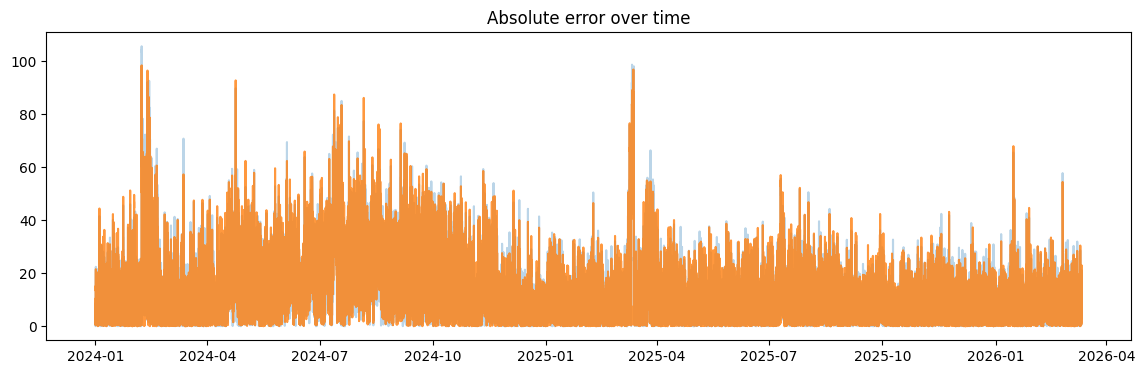

In [87]:
# Plot of worst errors
plt.figure(figsize=(14,4))
plt.plot(error_df['datetime'], error_df['abs_error_s1'], alpha=0.3)
plt.plot(error_df['datetime'], error_df['abs_error_s2'], alpha=0.8)
plt.title('Absolute error over time')
plt.show()

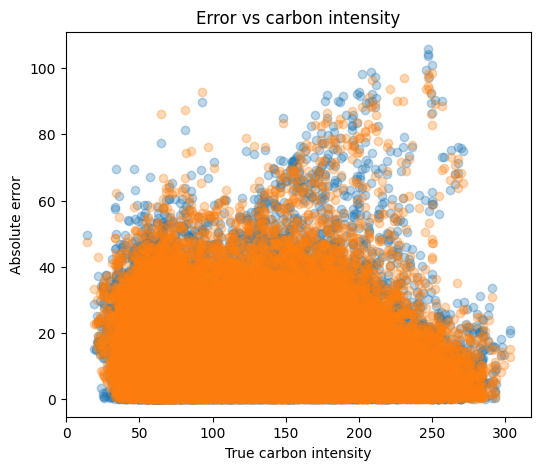

In [67]:
plt.figure(figsize=(6,5))
plt.scatter(error_df['y_true'], error_df['abs_error_s1'], alpha=0.3)
plt.scatter(error_df['y_true'], error_df['abs_error_s2'], alpha=0.3)
plt.xlabel('True carbon intensity')
plt.ylabel('Absolute error')
plt.title('Error vs carbon intensity')
plt.show()

In [74]:
print(pd.DataFrame(error_df['abs_error_s1'].describe()))

print(pd.DataFrame(error_df['abs_error_s2'].describe()))


       abs_error_s1
count  38234.000000
mean      12.934007
std       11.619122
min        0.001617
25%        4.484997
50%        9.713768
75%       18.058655
max      105.698074
       abs_error_s2
count  38234.000000
mean      12.963918
std       11.555519
min        0.000168
25%        4.486107
50%        9.718431
75%       18.330090
max       98.480515


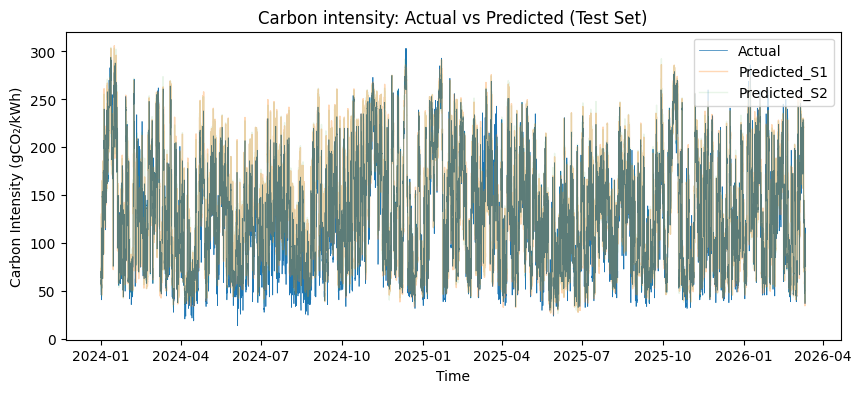

In [ ]:
# plotting pred
plt.figure(figsize=(10,4))
plt.plot(df.loc[X_test.index, 'datetime'], y_test, label='Actual', linewidth=0.5)
plt.plot(df.loc[X_test.index, 'datetime'], y_pred_stage1, label='Predicted_S1', linewidth=1, alpha=0.3)
plt.plot(df.loc[X_test.index, 'datetime'], y_pred_stage2, label='Predicted_S2', linewidth=1, alpha=0.1)

plt.legend()
plt.title('Carbon intensity: Actual vs Predicted (Test Set)')
plt.xlabel('Time')
plt.ylabel('Carbon Intensity (gCO₂/kWh)')
plt.show()

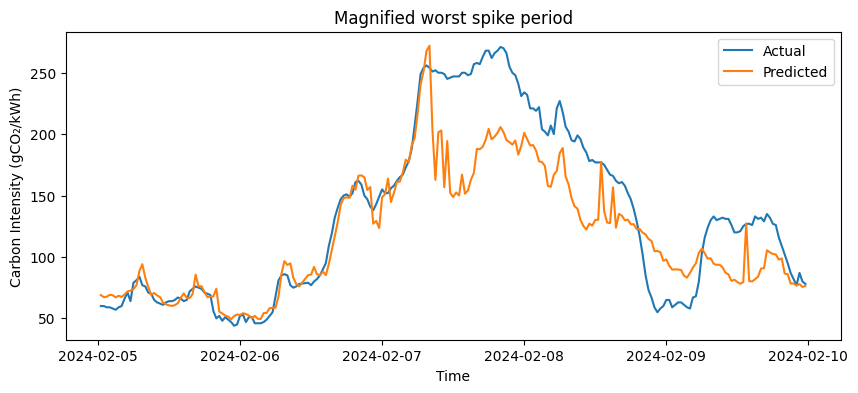

In [ ]:
# Zoom in on worst period
mask = (df.loc[X_test.index, 'datetime'] > '2024-02-05') & \
       (df.loc[X_test.index, 'datetime'] < '2024-02-10')

plt.figure(figsize=(10,4))
plt.plot(df.loc[X_test.index, 'datetime'][mask], y_test[mask], label='Actual')
plt.plot(df.loc[X_test.index, 'datetime'][mask], y_pred[mask], label='Predicted')
plt.legend()
plt.ylabel('Carbon Intensity (gCO₂/kWh)')
plt.xlabel('Time')
plt.title('Magnified worst spike period')
plt.show()

In [ ]:
# finer stage 2 grid search with refit to mae and rmse to compare
# overnight run

#params grid
param_grid_overnight = {
    'n_estimators': [1400, 1500, 1600],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.02, 0.03, 0.04],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 1, 5]
}

#split
tscv = TimeSeriesSplit(n_splits=5)

# set scoring to inlcude
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2',
    'max_err': 'neg_max_error'
}

# stage 2 finer
param_grid_overnight = {
    'n_estimators': [1450, 1500, 1550],
    'max_depth': [4, 5, 6],
    'learning_rate': [0.02, 0.03, 0.04],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0]
}

xgb_base = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

# NOTE: The following MAE results not saved and overwritten 

In [ ]:
# refit to mae
# RESULTS NOT SAVED AND OVERWRITTEN
# re run as mae_correct lower down
grid_mae = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_overnight,
    scoring=scoring,
    refit='mae',
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    return_train_score=False # added bc do not need
)

grid_mae.fit(X_train, y_train)

print('Overnight MAE grid best params:', grid_mae.best_params_)
print('Overnight MAE grid best score:', -grid_mae.best_score_)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.7; total time=   2.4s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.85; total time=   2.3s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.85; total time=   3.4s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.7; total time=   3.5s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=1.0; total time=   1.9s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.85; total time=   4.4s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsampl

# NOTE: The following RMSE results have overwritten the previous MAE refit results 
grid_mae renamed to gird_rmse

In [ ]:
# refit to rmse
# NAMING ERROR - refit to rmse but named mae
# has overwritten the mae gridsearch
grid_mae = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_overnight,
    scoring=scoring,
    refit='rmse',
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    return_train_score=False # added bc do not need
)

grid_mae.fit(X_train, y_train)

print('Overnight MAE grid best params:', grid_mae.best_params_)
print('Overnight MAE grid best score:', -grid_mae.best_score_)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.85; total time=   2.0s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.7; total time=   2.1s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.7; total time=   3.0s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=1.0; total time=   1.7s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.85; total time=   2.6s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.7; total time=   4.1s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample

In [108]:
# re naming the rmse grid and results
grid_rmse = grid_mae

print('Overnight RMSE grid best params:', grid_rmse.best_params_)
print('Overnight RMSE grid best score:', -grid_rmse.best_score_)

Overnight RMSE grid best params: {'colsample_bytree': 0.7, 'learning_rate': 0.04, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 1450, 'subsample': 1.0}
Overnight RMSE grid best score: 19.709365997124618


In [ ]:
# rmse results for overnight
rmse_results = pd.DataFrame(grid_rmse.cv_results_)[[
    'params',
    'mean_test_rmse',
    'mean_test_mae',
    'mean_test_r2',
    'mean_test_max_err'
]].copy() # nb remember to add this

rmse_results['mean_test_rmse'] = -rmse_results['mean_test_rmse']
rmse_results['mean_test_mae'] = -rmse_results['mean_test_mae']
rmse_results['mean_test_max_err'] = -rmse_results['mean_test_max_err']
rmse_results['mean_test_r2'] = -rmse_results['mean_test_r2']


rmse_results = rmse_results.sort_values('mean_test_rmse')
mae_results.head(5)

,params,mean_test_rmse,mean_test_mae,mean_test_r2,mean_test_max_err
192,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.731288,15.675898,0.899016,134.214835
195,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.738441,15.683276,0.898943,134.192831
189,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.737662,15.684521,0.898951,134.296124
227,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.709366,15.691143,0.899235,136.408099
230,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.714762,15.692219,0.899192,136.258636


# Rerun of MAE results beacuse overwritten above
saved as grid_mae_rerun

In [112]:
# RE RUN
# CORRECT MAE
# refit to mae
grid_mae_rerun = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_overnight,
    scoring=scoring,
    refit='mae',
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    return_train_score=False # added bc do not need
)

grid_mae_rerun.fit(X_train, y_train)

print('Overnight MAE grid best params:', grid_mae_rerun.best_params_)
print('Overnight MAE grid best score:', -grid_mae_rerun.best_score_)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.7; total time=   2.0s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.85; total time=   2.1s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.7; total time=   3.2s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.85; total time=   3.2s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=1.0; total time=   1.7s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample=0.7; total time=   4.1s
[CV] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=1, n_estimators=1450, subsample

In [126]:
# MAE RE RUN
# results for overnight
mae_rerun_results = pd.DataFrame(grid_mae_rerun.cv_results_)[[
    'params',
    'mean_test_rmse',
    'mean_test_mae',
    'mean_test_r2',
    'mean_test_max_err'
]].copy()

mae_rerun_results['mean_test_rmse'] = -mae_rerun_results['mean_test_rmse']
mae_rerun_results['mean_test_mae'] = -mae_rerun_results['mean_test_mae']
mae_rerun_results['mean_test_max_err'] = -mae_rerun_results['mean_test_max_err']
mae_rerun_results['mean_test_r2'] = -mae_rerun_results['mean_test_r2']

mae_rerun_results = mae_rerun_results.sort_values('mean_test_mae')
mae_rerun_results.head(5)


,params,mean_test_rmse,mean_test_mae,mean_test_r2,mean_test_max_err
192,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.731288,15.675898,-0.899016,134.214835
195,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.738441,15.683276,-0.898943,134.192831
189,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.737662,15.684521,-0.898951,134.296124
227,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.709366,15.691143,-0.899235,136.408099
230,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.714762,15.692219,-0.899192,136.258636


In [125]:
rmse_results.head(5)


,params,mean_test_rmse,mean_test_mae,mean_test_r2,mean_test_max_err
227,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.709366,15.691143,-0.899235,136.408099
230,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.714762,15.692219,-0.899192,136.258636
233,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.718078,15.693471,-0.899160,136.179605
192,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.731288,15.675898,-0.899016,134.214835
189,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",19.737662,15.684521,-0.898951,134.296124


In [127]:
# stage 3 gridsearch
param_grid_stage3 = {
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 3, 5]
}

In [128]:
# stage 3 mae gridsearch
best_mae_params = grid_mae.best_params_

xgb_stage3_mae = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    learning_rate=best_mae_params['learning_rate'],
    max_depth=best_mae_params['max_depth'],
    n_estimators=best_mae_params['n_estimators'],
    min_child_weight=best_mae_params['min_child_weight'],
    subsample=best_mae_params['subsample'],
    colsample_bytree=best_mae_params['colsample_bytree']
)

grid_stage3_mae = GridSearchCV(
    estimator=xgb_stage3_mae,
    param_grid=param_grid_stage3,
    scoring=scoring,
    refit='mae',
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    return_train_score=False
)

grid_stage3_mae.fit(X_train, y_train)

print('Stage 3 MAE best params:', grid_stage3_mae.best_params_)
print('Stage 3 MAE best score:', -grid_stage3_mae.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=1; total time=   3.8s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=3; total time=   3.8s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=3; total time=   5.3s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=1; total time=   5.3s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=1; total time=   6.7s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=3; total time=   6.7s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=5; total time=   3.7s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=3; total time=   8.0s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=1; total time=   8.1s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=5; total time=   5.1s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=3; total time=   9.3s
[CV] END .................gamma=0, reg_alpha=0,

In [129]:
# stage 3 mae results
stage3_mae_results = pd.DataFrame(grid_stage3_mae.cv_results_)[[
    'params',
    'mean_test_rmse',
    'mean_test_mae',
    'mean_test_r2',
    'mean_test_max_err'
]].copy()

stage3_mae_results['mean_test_rmse'] = -stage3_mae_results['mean_test_rmse']
stage3_mae_results['mean_test_mae'] = -stage3_mae_results['mean_test_mae']
stage3_mae_results['mean_test_max_err'] = -stage3_mae_results['mean_test_max_err']

stage3_mae_results = stage3_mae_results.sort_values('mean_test_mae')
stage3_mae_results.head(10)

,params,mean_test_rmse,mean_test_mae,mean_test_r2,mean_test_max_err
3,"{'gamma': 0, 'reg_alpha': 0.01, 'reg_lambda': 1}",19.658582,15.657857,0.899723,136.535596
0,"{'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 1}",19.709366,15.691143,0.899235,136.408099
18,"{'gamma': 0.3, 'reg_alpha': 0, 'reg_lambda': 1}",19.721998,15.697945,0.899089,136.003882
12,"{'gamma': 0.1, 'reg_alpha': 0.01, 'reg_lambda'...",19.724553,15.701469,0.899059,137.804352
9,"{'gamma': 0.1, 'reg_alpha': 0, 'reg_lambda': 1}",19.746535,15.723928,0.898922,136.751639
21,"{'gamma': 0.3, 'reg_alpha': 0.01, 'reg_lambda'...",19.753991,15.735072,0.898716,137.983640
1,"{'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 3}",19.796636,15.742122,0.898325,136.940076
10,"{'gamma': 0.1, 'reg_alpha': 0, 'reg_lambda': 3}",19.837819,15.769197,0.897943,136.987817
15,"{'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 1}",19.844015,15.807713,0.897859,136.325302
24,"{'gamma': 0.3, 'reg_alpha': 0.1, 'reg_lambda': 1}",19.857244,15.809595,0.897776,135.852737


In [130]:
# stage 3 rmse gridsearch
best_rmse_params = grid_rmse.best_params_

xgb_stage3_rmse = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    learning_rate=best_rmse_params['learning_rate'],
    max_depth=best_rmse_params['max_depth'],
    n_estimators=best_rmse_params['n_estimators'],
    min_child_weight=best_rmse_params['min_child_weight'],
    subsample=best_rmse_params['subsample'],
    colsample_bytree=best_rmse_params['colsample_bytree']
)

grid_stage3_rmse = GridSearchCV(
    estimator=xgb_stage3_rmse,
    param_grid=param_grid_stage3,
    scoring=scoring,
    refit='rmse',
    cv=tscv,
    verbose=2,
    n_jobs=-1,
    return_train_score=False
)

grid_stage3_rmse.fit(X_train, y_train)

print('Stage 3 RMSE best params:', grid_stage3_rmse.best_params_)
print('Stage 3 RMSE best score:', -grid_stage3_rmse.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=3; total time=   3.4s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=1; total time=   3.6s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=3; total time=   4.8s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=1; total time=   4.9s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=3; total time=   6.3s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=1; total time=   6.5s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=5; total time=   3.6s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=1; total time=   7.6s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=3; total time=   7.6s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=5; total time=   5.0s
[CV] END .................gamma=0, reg_alpha=0, reg_lambda=1; total time=   9.0s
[CV] END .................gamma=0, reg_alpha=0,

In [131]:
# stage 3 rmse results

stage3_rmse_results = pd.DataFrame(grid_stage3_rmse.cv_results_)[[
    'params',
    'mean_test_rmse',
    'mean_test_mae',
    'mean_test_r2',
    'mean_test_max_err'
]].copy()

stage3_rmse_results['mean_test_rmse'] = -stage3_rmse_results['mean_test_rmse']
stage3_rmse_results['mean_test_mae'] = -stage3_rmse_results['mean_test_mae']
stage3_rmse_results['mean_test_max_err'] = -stage3_rmse_results['mean_test_max_err']

stage3_rmse_results = stage3_rmse_results.sort_values('mean_test_rmse')
stage3_rmse_results.head(10)

,params,mean_test_rmse,mean_test_mae,mean_test_r2,mean_test_max_err
3,"{'gamma': 0, 'reg_alpha': 0.01, 'reg_lambda': 1}",19.658582,15.657857,0.899723,136.535596
0,"{'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 1}",19.709366,15.691143,0.899235,136.408099
18,"{'gamma': 0.3, 'reg_alpha': 0, 'reg_lambda': 1}",19.721998,15.697945,0.899089,136.003882
12,"{'gamma': 0.1, 'reg_alpha': 0.01, 'reg_lambda'...",19.724553,15.701469,0.899059,137.804352
9,"{'gamma': 0.1, 'reg_alpha': 0, 'reg_lambda': 1}",19.746535,15.723928,0.898922,136.751639
21,"{'gamma': 0.3, 'reg_alpha': 0.01, 'reg_lambda'...",19.753991,15.735072,0.898716,137.983640
1,"{'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 3}",19.796636,15.742122,0.898325,136.940076
10,"{'gamma': 0.1, 'reg_alpha': 0, 'reg_lambda': 3}",19.837819,15.769197,0.897943,136.987817
15,"{'gamma': 0.1, 'reg_alpha': 0.1, 'reg_lambda': 1}",19.844015,15.807713,0.897859,136.325302
6,"{'gamma': 0, 'reg_alpha': 0.1, 'reg_lambda': 1}",19.844555,15.809735,0.897948,137.288376


In [132]:
# stage 3 predictions
y_pred_final_mae = grid_stage3_mae.best_estimator_.predict(X_test)
y_pred_final_rmse = grid_stage3_rmse.best_estimator_.predict(X_test)

In [ ]:
# placeholder for plots needed

# plot 1: actual vs predicted
# plt.figure(figsize=(10,4))
# plt.scatter(y_test, y_pred, alpha=0.3)

# plt.plot(
#     [y_test.min(), y_test.max()],
#     [y_test.min(), y_test.max()],
#     color='red'
# )

# plt.xlabel('Actual')
# plt.ylabel('Predicted')
# plt.title('Actual vs Predicted')
# plt.show()

In [ ]:
# plot 2: timeseries line plot
# plt.figure(figsize=(10,4))
# plt.plot(y_test.values, label='Actual')
# plt.plot(y_pred, label='Predicted')

# plt.legend()
# plt.title('Carbon intensity over time')
# plt.show()

In [ ]:
# plot 3: residual dist.
# residuals = y_test - y_pred

# plt.hist(residuals, bins=50)
# plt.title('Residual distribution')
# plt.show()

# Why timeseries even though xgboost: 
- xgboost is not a sequential model 
- the data generating process is temporal 

In [ ]:
#